# 03 Unbalanced phases

*BUILD*

**Question:** Do all three phases see the same voltage?

- **Model:** bundled IEEE 13-node feeder; inspect bus 671 phase by phase.
- **Outcome:** run unbalanced load flow, inspect the SLD, and read phase-specific voltages.
- **Boundary:** this bundled model demonstrates phase readback; it does not validate a real feeder.


## ⚙ Setup

Run the bootstrap once to load lesson helpers and prepare the Colab workspace.


In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — target bus

Set the bundled IEEE 13-node feeder and target bus `671`; keep phases A/B/C separate.


In [2]:
#@title 2. Inputs — feeder and bus to inspect
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
BUS_TO_INSPECT = "671"
table(
    ["declared input", "value", "unit"],
    [
        ("network", "IEEE 13-node feeder", "text"),
        ("bus to inspect", BUS_TO_INSPECT, "bus"),
        ("phases", "A / B / C", "text"),
    ],
)

declared input  value                unit
--------------  -------------------  ----
network         IEEE 13-node feeder  text
bus to inspect  671                  bus
phases          A / B / C            text


## ▶ Run — unbalanced load flow

Run `cept run --demo unbalanced-load-flow --network ieee13`; inspect the full multiphase result rather than a balanced average.


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept run --demo unbalanced-load-flow \
    --network ieee13 \
    --out runs/02-ieee13-unbalanced \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the unbalanced load flow (IEEE 13-node) and saved the evidence
Saved run          runs\02-ieee13-unbalanced
Case fingerprint   4716c9c07f02 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\02-ieee13-unbalanced --format text


## 📊 Explore — multiphase SLD

Open the SLD to inspect topology, regulator taps, switches, and phase connections.


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
display_sld(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
611,—,—,0.9608 pu @ 115.74°,OK
632,1.0143 pu @ -2.53°,1.0289 pu @ -121.76°,1.0042 pu @ 117.77°,OK
633,1.0113 pu @ -2.59°,1.0270 pu @ -121.81°,1.0015 pu @ 117.76°,OK
634,0.9872 pu @ -3.28°,1.0084 pu @ -122.27°,0.9825 pu @ 117.27°,OK
645,—,1.0197 pu @ -121.94°,1.0023 pu @ 117.79°,OK
646,—,1.0180 pu @ -122.02°,1.0002 pu @ 117.84°,OK
650,0.9999 pu @ -0.01°,1.0000 pu @ -120.01°,0.9999 pu @ 119.99°,OK
652,0.9753 pu @ -5.32°,—,—,OK
670,1.0040 pu @ -3.46°,1.0319 pu @ -121.97°,0.9898 pu @ 117.10°,OK
671,0.9828 pu @ -5.37°,1.0403 pu @ -122.39°,0.9649 pu @ 115.99°,OK


## 📊 Results — bus 671 by phase

Read `results.json` and inspect each voltage/angle row for phases 1–3. Do not replace them with one average.


In [5]:
#@title 5. Engineering result — bus 671 by phase
results = read(RUN_DIR / "results.json")
bus_rows = [
    row for row in results["load_flow"]["bus_voltages"]
    if row["bus"].lower() == BUS_TO_INSPECT.lower()
]
table(
    ["bus", "phase", "voltage", "angle", "unit"],
    [
        (row["bus"], row["phase"], row["v_pu"], row["v_angle_deg"], "pu / deg")
        for row in bus_rows
    ],
)
assert {row["phase"] for row in bus_rows} == {1, 2, 3}

bus  phase  voltage   angle      unit
---  -----  --------  ---------  --------
671  1      0.982797  -5.3738    pu / deg
671  2      1.040275  -122.3902  pu / deg
671  3      0.964889  115.9871   pu / deg


## 📈 Plot — phase spread

Plot voltage magnitudes at bus 671; read the A/B/C spread against nominal 1.0 pu.

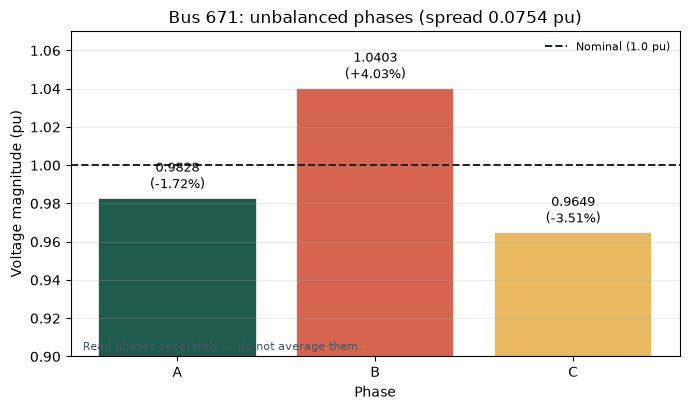

In [6]:
#@title 6. Plot — phase voltages at bus 671 (unbalanced)
import matplotlib.pyplot as plt

phase_values = {int(r["phase"]): float(r["v_pu"]) for r in bus_rows}
order = [1, 2, 3]; labels = ["A", "B", "C"]
colors = ["#1f5b4d", "#d5654e", "#e9b95f"]
vals = [phase_values[p] for p in order]
spread = max(vals) - min(vals)

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2)
ax.axhline(1.0, color="#17231f", linestyle="--", linewidth=1.4, label="Nominal (1.0 pu)")
ax.set_title(f"Bus {BUS_TO_INSPECT}: unbalanced phases (spread {spread:.4f} pu)")
ax.set_xlabel("Phase"); ax.set_ylabel("Voltage magnitude (pu)")
ax.set_ylim(0.90, 1.07)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{v:.4f}\n({(v - 1.0) * 100.0:+.2f}%)", ha="center", va="bottom", fontsize=9)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="y", alpha=0.25)
ax.text(0.02, 0.02, "Read phases separately — do not average them.", transform=ax.transAxes,
        fontsize=8, color="#475569")
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)


## ✓ Verify — saved run

Run `cept verify` to check the converged run and artifact digests against the receipt. This supports run/evidence integrity, not independent feeder validation.


In [7]:
# 6. Verify — check this exact saved run
!cept verify runs/02-ieee13-unbalanced --format text

CEPT study check: PASSED
----------------------------
Study              Unbalanced load flow (OpenDSS)
Case fingerprint   4716c9c07f02 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


## ◇ Interpret

- **Read:** bus 671 phase A/B/C separately; one average can hide imbalance.
- **Supports:** phase-specific values for the bundled feeder.
- **Does not prove:** independent validation of a real distribution network.

**◇ Next:** choose another named bus and repeat without averaging the phases.

## ◇ Optional — direct solver comparison

Run these cells in order to compare direct OpenDSS readback with persisted CEPT values; they are optional details, not a second product workflow.

In [8]:
#@title Under the hood - direct OpenDSS solve (optional)
MASTER_DSS = ieee13_master()
import opendssdirect as dss

dss.Basic.ClearAll()
dss.Basic.DataPath(str(MASTER_DSS.parent))
dss.Text.Command(f'Redirect "{MASTER_DSS}"')
dss.Text.Command('CalcVoltageBases')
dss.Text.Command('Solve')
assert dss.Solution.Converged()
os.chdir(WORKSPACE)
print("Direct OpenDSS solve finished: the IEEE 13-node feeder converged.")


Direct OpenDSS solve finished: the IEEE 13-node feeder converged.


In [9]:
#@title Under the hood — direct OpenDSS readback (optional)
dss.Circuit.SetActiveBus(BUS_TO_INSPECT)
direct_values = dss.Bus.puVmagAngle()
direct_by_phase = {phase: float(direct_values[2 * (phase - 1)]) for phase in (1, 2, 3)}
table(['source', 'bus', 'phase', 'voltage magnitude', 'unit'], [('direct OpenDSS', BUS_TO_INSPECT, phase, value, 'pu') for phase, value in direct_by_phase.items()])
assert all(value > 0 for value in direct_by_phase.values())

source          bus  phase  voltage magnitude   unit
--------------  ---  -----  ------------------  ----
direct OpenDSS  671  1      0.9827953877537872  pu
direct OpenDSS  671  2      1.040273943965177   pu
direct OpenDSS  671  3      0.9648999396286697  pu


In [10]:
#@title Compare solver outputs (optional details)
RUN_DIR = WORKSPACE / "runs" / "02-ieee13-unbalanced"
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
cept_rows = [row for row in results["load_flow"]["bus_voltages"] if row["bus"].lower() == BUS_TO_INSPECT.lower()]
cept_by_phase = {row["phase"]: row["v_pu"] for row in cept_rows}
table(
    ["phase", "direct OpenDSS pu", "CEPT pu", "|difference| pu"],
    [(phase, direct_by_phase[phase], cept_by_phase[phase], abs(direct_by_phase[phase] - cept_by_phase[phase])) for phase in (1, 2, 3)],
)
max_abs_diff_pu = max(abs(direct_by_phase[phase] - cept_by_phase[phase]) for phase in (1, 2, 3))
print()
print("Direct OpenDSS and CEPT agree on all 3 phases")
print("--------------------------------------------")
print(f"Result        {'PASSED' if verify_summary['passed'] else 'Needs attention'}")
print(f"Largest phase difference: {max_abs_diff_pu:.2e} per unit (limit 1e-4 per unit)")
print("A small difference is rounding, not a different answer.")
assert verify_summary["status"] == "PASS"
assert verify_summary["passed"] is True
assert set(cept_by_phase) == {1, 2, 3}
assert max_abs_diff_pu < 1e-4


phase  direct OpenDSS pu   CEPT pu   |difference| pu
-----  ------------------  --------  ----------------------
1      0.9827953877537872  0.982797  1.6122462128675963e-06
2      1.040273943965177   1.040275  1.0560348231436478e-06
3      0.9648999396286697  0.964889  1.0939628669714985e-05

Direct OpenDSS and CEPT agree on all 3 phases
--------------------------------------------
Result        PASSED
Largest phase difference: 1.09e-05 per unit (limit 1e-4 per unit)
A small difference is rounding, not a different answer.
